In [1]:
from pathlib import Path
import joblib

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import ast

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.utils.validation import check_is_fitted

from sklearn.pipeline import Pipeline

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV


from sklearn.metrics import mean_squared_error, r2_score

from sklearn.preprocessing import MultiLabelBinarizer, label_binarize, OneHotEncoder, LabelEncoder
from collections import Counter
from sklearn.dummy import DummyRegressor

from collections import defaultdict

from sklearn.ensemble import RandomForestRegressor

In [2]:
sns.set_theme(context='notebook', style='whitegrid', palette='muted')

In [3]:
data_dir = Path('../../results')

#Load dfs
train = pd.read_csv(data_dir / 'train_clean.csv')
test = pd.read_csv(data_dir / 'test_clean.csv')

In [4]:
# Define target variables

y_train = train['averageRating']
y_test = test['averageRating']

In [5]:
# Create copies of the dataframes to manipulate
df_train = train.copy()
df_test = test.copy()

# Pre-Processing

Like we did for NN, we'll use fewer features than for the other models, in order to cut down on time for hyperparameter tuning.
- We'll only keep top 9 countries and regions
- delete hasAwards (corr to hasAwardsAndNominations)

In [6]:
def check_columns(train_df, test_df):
    train_cols = set(train_df.columns)
    test_cols = set(test_df.columns)
    if train_cols == test_cols:
        print("Train and test columns match.")
    else:
        print("Train and test columns DO NOT match.")
        print("Only in train:", train_cols - test_cols)
        print("Only in test:", test_cols - train_cols)

check_columns(df_train, df_test)


Train and test columns match.


In [7]:
# drop target variables + hasAwards
df_train.drop(columns=['rating', 'averageRating', 'hasAwards'], inplace=True) 
df_test.drop(columns=['rating', 'averageRating', 'hasAwards'], inplace=True)

check_columns(df_train, df_test)
df_train.columns

Train and test columns match.


Index(['originalTitle', 'startYear', 'runtimeMinutes', 'numVotes',
       'totalImages', 'totalCredits', 'titleType', 'canHaveEpisodes',
       'numRegions', 'countryOfOrigin', 'genres', 'companiesNumber', 'regions',
       'externalLinks', 'writerCredits', 'numGenres', 'criticReviewsRatio',
       'hasAwardsOrNominations', 'hasVideos', 'hasCriticsReviews',
       'hasUserReviews', 'moreDirectorsCredits', 'hasQuotes',
       'moreCountriesOfOrigin'],
      dtype='object')

In [8]:
num_cols = df_train.dtypes[(df_train.dtypes == 'float64') | (df_train.dtypes == 'int64')].index
bool_cols = df_train.dtypes[df_train.dtypes == 'bool'].index
cat_cols = df_train.dtypes[df_train.dtypes == 'object'].drop(['originalTitle','countryOfOrigin','genres','regions']).index #drop the target var and lists

In [9]:
num_cols, bool_cols, cat_cols #NB: cat_cols only contains titleType, this is for rating as a target

(Index(['startYear', 'runtimeMinutes', 'numVotes', 'totalImages',
        'totalCredits', 'numRegions', 'companiesNumber', 'externalLinks',
        'writerCredits', 'numGenres', 'criticReviewsRatio'],
       dtype='object'),
 Index(['canHaveEpisodes', 'hasAwardsOrNominations', 'hasVideos',
        'hasCriticsReviews', 'hasUserReviews', 'moreDirectorsCredits',
        'hasQuotes', 'moreCountriesOfOrigin'],
       dtype='object'),
 Index(['titleType'], dtype='object'))

In [10]:
# Lists: countryOfOrigin, genres, regions	
df_train['countryOfOrigin'] = df_train['countryOfOrigin'].apply(ast.literal_eval)
df_train['genres'] = df_train['genres'].apply(ast.literal_eval)
df_train['regions'] = df_train['regions'].apply(ast.literal_eval)

df_test['countryOfOrigin'] = df_test['countryOfOrigin'].apply(ast.literal_eval)
df_test['genres'] = df_test['genres'].apply(ast.literal_eval)
df_test['regions'] = df_test['regions'].apply(ast.literal_eval)

In [11]:
def clean_geo(geo, top_geo):
    """    Clean geographical data by replacing less common entries with 'Other'."""
    return [c if c in top_geo else "Other" for c in geo]

In [12]:
all_countries = [country for countries in df_train['countryOfOrigin'] for country in countries]
country_counts = Counter(all_countries) #Counter: dictionary 'country':count

top_n_countries = 9
top_countries = set([country for country, _ in country_counts.most_common(top_n_countries)]) 

df_train['country_cleaned'] = df_train['countryOfOrigin'].apply(clean_geo, top_geo=top_countries)
df_test['country_cleaned'] = df_test['countryOfOrigin'].apply(clean_geo, top_geo=top_countries)

In [13]:
all_regions = [region for regions in df_train['regions'] for region in regions]
region_counts = Counter(all_regions) #Counter: dictionary 'country':count

top_n_regions = 9
top_regions = set([region for region, _ in region_counts.most_common(top_n_regions)])

df_train['region_cleaned'] = df_train['regions'].apply(clean_geo, top_geo=top_regions)
df_test['region_cleaned'] = df_test['regions'].apply(clean_geo, top_geo=top_regions)

In [14]:
# Custom transformer for MultiLabelBinarizer
class MultiLabelBinarizerTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.mlb = MultiLabelBinarizer()

    def fit(self, X, y=None):
        self.mlb.fit(X)
        return self
    
    def transform(self, X):
        return self.mlb.transform(X)
    
    def get_feature_names_out(self, input_features=None):
        'Return feature names for output features'
        check_is_fitted(self.mlb)
        return np.array([f"mlb__{label}" for label in self.mlb.classes_])

In [15]:
def build_preprocessor(num_cols, bool_cols, cat_cols):
    return ColumnTransformer(
        transformers=[
            ('num', 'passthrough', num_cols), #TREES: NO SCALING NEEDED
            ('bool', 'passthrough', bool_cols),
            ('cat', OneHotEncoder(), cat_cols),  # No need for drop='first': RF handles redundant feats
            ('countries', MultiLabelBinarizerTransformer(), 'country_cleaned'),
            ('genres', MultiLabelBinarizerTransformer(), 'genres'),
            ('regions', MultiLabelBinarizerTransformer(), 'region_cleaned')
        ]
    )

# Hyperparameter Tuning

In [16]:
pipeline= Pipeline(steps=[
    ('preprocessor', build_preprocessor(num_cols, bool_cols, cat_cols)),
    ('clf', RandomForestRegressor(random_state=42))
])

In [17]:
param_grid_100 = {
    'clf__n_estimators': [100],
    'clf__max_depth': [None, 5, 15, 25],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 5, 10],
    'clf__max_features': [None, 'log2', 'sqrt', 0.5]
}

param_grid_300 = {
    'clf__n_estimators': [300],
    'clf__max_depth': [None, 5, 15, 25],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 5, 10],
    'clf__max_features': [None, 'log2', 'sqrt', 0.5]
}

param_grid_500 = {
    'clf__n_estimators': [500],
    'clf__max_depth': [None, 5, 15, 25],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 5, 10],
    'clf__max_features': [None, 'log2', 'sqrt', 0.5]
}

In [18]:
random_search_100 = RandomizedSearchCV(
    pipeline,
    param_distributions=param_grid_100,
    n_iter=100,
    cv=3,
    scoring=['neg_mean_squared_error', 'r2'],
    refit='r2',
    verbose=2,
    random_state=0,
    n_jobs=-1,
    return_train_score=True
)

random_search_100.fit(df_train, y_train)

print(f"BEST MODEL:")
best_index_100 = random_search_100.best_index_
val_mse_100 = -random_search_100.cv_results_['mean_test_neg_mean_squared_error'][best_index_100]
train_mse_100 = -random_search_100.cv_results_['mean_train_neg_mean_squared_error'][best_index_100]
train_r2_100 = random_search_100.cv_results_['mean_train_r2'][best_index_100]

print(f"Validation R²: {random_search_100.best_score_:.3f}; vs R² on train: {train_r2_100:.3f}")
print(f"MSE on validation: {val_mse_100:.3f}; vs MSE on train: {train_mse_100:.3f}")
print(f"Best parameters: {random_search_100.best_params_}")

Fitting 3 folds for each of 100 candidates, totalling 300 fits
BEST MODEL:
Validation R²: 0.419; vs R² on train: 0.918
MSE on validation: 1.056; vs MSE on train: 0.150
Best parameters: {'clf__n_estimators': 100, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_features': 0.5, 'clf__max_depth': None}


In [19]:
random_search_300 = RandomizedSearchCV(
    pipeline,
    param_distributions=param_grid_300,
    n_iter=100,
    cv=3,
    scoring=['neg_mean_squared_error', 'r2'],
    refit='r2',
    verbose=2,
    random_state=0,
    n_jobs=-1,
    return_train_score=True
)

random_search_300.fit(df_train, y_train)

print(f"BEST MODEL (300 estimators):")
best_index_300 = random_search_300.best_index_
val_mse_300 = -random_search_300.cv_results_['mean_test_neg_mean_squared_error'][best_index_300]
train_mse_300 = -random_search_300.cv_results_['mean_train_neg_mean_squared_error'][best_index_300]
train_r2_300 = random_search_300.cv_results_['mean_train_r2'][best_index_300]

print(f"Validation R²: {random_search_300.best_score_:.3f}; vs R² on train: {train_r2_300:.3f}")
print(f"MSE on validation: {val_mse_300:.3f}; vs MSE on train: {train_mse_300:.3f}")
print(f"Best parameters: {random_search_300.best_params_}")

Fitting 3 folds for each of 100 candidates, totalling 300 fits
BEST MODEL (300 estimators):
Validation R²: 0.423; vs R² on train: 0.920
MSE on validation: 1.048; vs MSE on train: 0.145
Best parameters: {'clf__n_estimators': 300, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_features': 0.5, 'clf__max_depth': None}


In [20]:
random_search_500 = RandomizedSearchCV(
    pipeline,
    param_distributions=param_grid_500,
    n_iter=100,
    cv=3,
    scoring=['neg_mean_squared_error', 'r2'],
    refit='r2',
    verbose=2,
    random_state=0,
    n_jobs=-1,
    return_train_score=True
)

random_search_500.fit(df_train, y_train)

print(f"BEST MODEL (500 estimators):")
best_index_500 = random_search_500.best_index_
val_mse_500 = -random_search_500.cv_results_['mean_test_neg_mean_squared_error'][best_index_500]
train_mse_500 = -random_search_500.cv_results_['mean_train_neg_mean_squared_error'][best_index_500]
train_r2_500 = random_search_500.cv_results_['mean_train_r2'][best_index_500]

print(f"Validation R²: {random_search_500.best_score_:.3f}; vs R² on train: {train_r2_500:.3f}")
print(f"MSE on validation: {val_mse_500:.3f}; vs MSE on train: {train_mse_500:.3f}")
print(f"Best parameters: {random_search_500.best_params_}")

Fitting 3 folds for each of 100 candidates, totalling 300 fits
BEST MODEL (500 estimators):
Validation R²: 0.424; vs R² on train: 0.921
MSE on validation: 1.047; vs MSE on train: 0.144
Best parameters: {'clf__n_estimators': 500, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_features': 0.5, 'clf__max_depth': None}


In [21]:
cv_results_100 = pd.DataFrame(random_search_100.cv_results_)
cv_results_100['overfitting_gap'] = cv_results_100['mean_train_r2'] - cv_results_100['mean_test_r2']

cv_results_300 = pd.DataFrame(random_search_300.cv_results_)
cv_results_300['overfitting_gap'] = cv_results_300['mean_train_r2'] - cv_results_300['mean_test_r2']

cv_results_500 = pd.DataFrame(random_search_500.cv_results_)
cv_results_500['overfitting_gap'] = cv_results_500['mean_train_r2'] - cv_results_500['mean_test_r2']

In [ ]:
"""
cv_results_100.to_csv(data_dir / "cv_results_rf_100.csv", index=False)
cv_results_300.to_csv(data_dir / "cv_results_rf_300.csv", index=False)
cv_results_500.to_csv(data_dir / "cv_results_rf_500.csv", index=False)
"""

In [23]:
pd.set_option("display.max_colwidth", None)

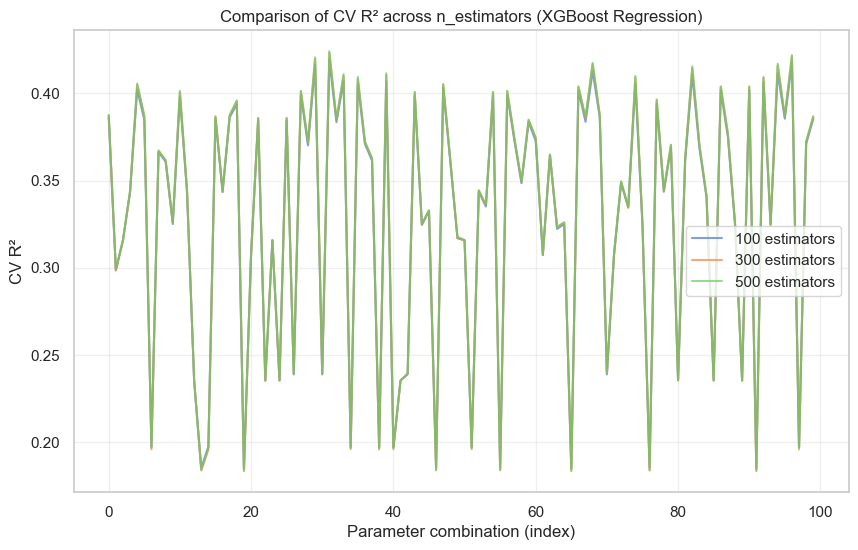

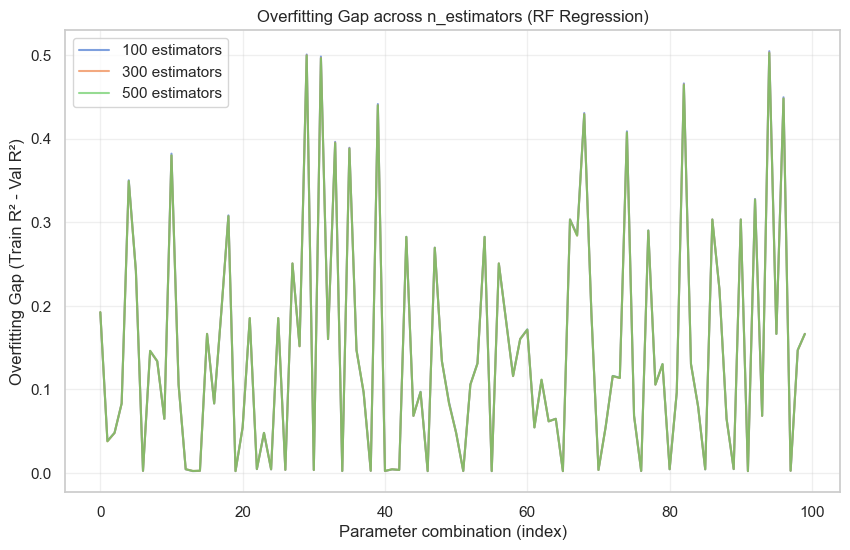

In [24]:
# First plot - CV R² scores
plt.figure(figsize=(10, 6))
plt.plot(cv_results_100.index, cv_results_100["mean_test_r2"], 
         label="100 estimators", alpha=0.7)
plt.plot(cv_results_300.index, cv_results_300["mean_test_r2"], 
         label="300 estimators", alpha=0.7)
plt.plot(cv_results_500.index, cv_results_500["mean_test_r2"], 
         label="500 estimators", alpha=0.7)
plt.xlabel("Parameter combination (index)")
plt.ylabel("CV R²")
plt.title("Comparison of CV R² across n_estimators (XGBoost Regression)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Second plot - Overfitting gap
plt.figure(figsize=(10, 6))
plt.plot(cv_results_100.index, cv_results_100["overfitting_gap"], 
         label="100 estimators", alpha=0.7)
plt.plot(cv_results_300.index, cv_results_300["overfitting_gap"], 
         label="300 estimators", alpha=0.7)
plt.plot(cv_results_500.index, cv_results_500["overfitting_gap"], 
         label="500 estimators", alpha=0.7)
plt.xlabel("Parameter combination (index)")
plt.ylabel("Overfitting Gap (Train R² - Val R²)")
plt.title("Overfitting Gap across n_estimators (RF Regression)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The growing number of estimators has no influence on the performances.

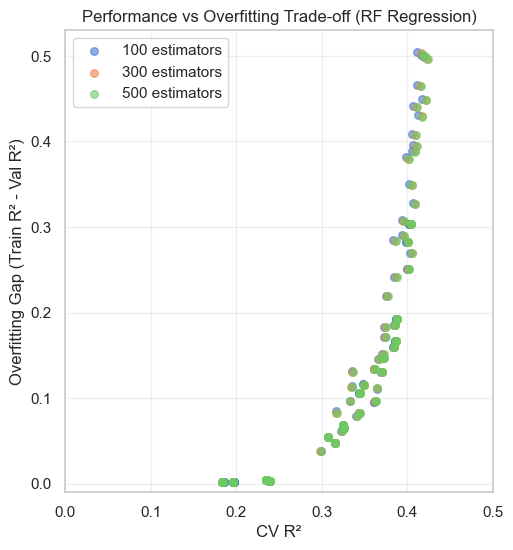

In [32]:
plt.figure(figsize=(10, 6))

plt.scatter(cv_results_100["mean_test_r2"], cv_results_100["overfitting_gap"], 
           alpha=0.6, label="100 estimators", s=30)
plt.scatter(cv_results_300["mean_test_r2"], cv_results_300["overfitting_gap"], 
           alpha=0.6, label="300 estimators", s=30)
plt.scatter(cv_results_500["mean_test_r2"], cv_results_500["overfitting_gap"], 
           alpha=0.6, label="500 estimators", s=30)

plt.xlabel("CV R²")
plt.ylabel("Overfitting Gap (Train R² - Val R²)")
plt.title("Performance vs Overfitting Trade-off (RF Regression)")
plt.legend()
plt.grid(True, alpha=0.3)

# Adjust limits for regression R² values (typically 0 to 1)
plt.xlim(left=0, right=0.5)
plt.ylim(bottom=-0.01) 
plt.gca().set_aspect('equal', adjustable='box')

plt.show()

Exponential trend.  
The models reach higher performances than xgboost (XGboost: max R2 was 0.397, here 0.424), and, given the same performance, they are slightly less overfitted.

In [35]:
cv_results_100.sort_values(
    by=["mean_test_r2", "overfitting_gap"], 
    ascending=[False, True]
).head(15)[['params','mean_train_r2', 'mean_test_r2', 'overfitting_gap']]

,params,mean_train_r2,mean_test_r2,overfitting_gap
31,"{'clf__n_estimators': 100, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_features': 0.5, 'clf__max_depth': None}",0.917613,0.419259,0.498354
96,"{'clf__n_estimators': 100, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 1, 'clf__max_features': 0.5, 'clf__max_depth': None}",0.867240,0.417630,0.449610
29,"{'clf__n_estimators': 100, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_features': 'sqrt', 'clf__max_depth': None}",0.917150,0.416365,0.500785
68,"{'clf__n_estimators': 100, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_features': 0.5, 'clf__max_depth': 25}",0.843463,0.412739,0.430724
94,"{'clf__n_estimators': 100, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_features': None, 'clf__max_depth': None}",0.916530,0.411741,0.504789
82,"{'clf__n_estimators': 100, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 1, 'clf__max_features': None, 'clf__max_depth': None}",0.877019,0.410860,0.466159
33,"{'clf__n_estimators': 100, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 1, 'clf__max_features': None, 'clf__max_depth': None}",0.803313,0.407100,0.396213
39,"{'clf__n_estimators': 100, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_features': None, 'clf__max_depth': 25}",0.848402,0.406917,0.441485
92,"{'clf__n_estimators': 100, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 1, 'clf__max_features': 0.5, 'clf__max_depth': 25}",0.734127,0.406345,0.327782
74,"{'clf__n_estimators': 100, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 1, 'clf__max_features': None, 'clf__max_depth': 25}",0.814722,0.405880,0.408842


In [36]:
cv_results_300.sort_values(
    by=["mean_test_r2", "overfitting_gap"], 
    ascending=[False, True]
).head(15)[['params','mean_train_r2', 'mean_test_r2', 'overfitting_gap']]

,params,mean_train_r2,mean_test_r2,overfitting_gap
31,"{'clf__n_estimators': 300, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_features': 0.5, 'clf__max_depth': None}",0.920101,0.423445,0.496655
96,"{'clf__n_estimators': 300, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 1, 'clf__max_features': 0.5, 'clf__max_depth': None}",0.869523,0.421455,0.448068
29,"{'clf__n_estimators': 300, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_features': 'sqrt', 'clf__max_depth': None}",0.919626,0.419826,0.499800
68,"{'clf__n_estimators': 300, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_features': 0.5, 'clf__max_depth': 25}",0.846339,0.416916,0.429423
94,"{'clf__n_estimators': 300, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_features': None, 'clf__max_depth': None}",0.919038,0.415891,0.503147
82,"{'clf__n_estimators': 300, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 1, 'clf__max_features': None, 'clf__max_depth': None}",0.879429,0.414545,0.464884
39,"{'clf__n_estimators': 300, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_features': None, 'clf__max_depth': 25}",0.850427,0.410480,0.439947
33,"{'clf__n_estimators': 300, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 1, 'clf__max_features': None, 'clf__max_depth': None}",0.805408,0.410180,0.395229
74,"{'clf__n_estimators': 300, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 1, 'clf__max_features': None, 'clf__max_depth': 25}",0.816564,0.409246,0.407318
92,"{'clf__n_estimators': 300, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 1, 'clf__max_features': 0.5, 'clf__max_depth': 25}",0.736248,0.409120,0.327128


In [34]:
cv_results_500.sort_values(
    by=["mean_test_r2", "overfitting_gap"], 
    ascending=[False, True]
).head(15)[['params','mean_train_r2', 'mean_test_r2', 'overfitting_gap']]

,params,mean_train_r2,mean_test_r2,overfitting_gap
31,"{'clf__n_estimators': 500, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_features': 0.5, 'clf__max_depth': None}",0.920569,0.424242,0.496327
96,"{'clf__n_estimators': 500, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 1, 'clf__max_features': 0.5, 'clf__max_depth': None}",0.869918,0.421955,0.447964
29,"{'clf__n_estimators': 500, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_features': 'sqrt', 'clf__max_depth': None}",0.920080,0.420696,0.499384
68,"{'clf__n_estimators': 500, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_features': 0.5, 'clf__max_depth': 25}",0.846568,0.417485,0.429083
94,"{'clf__n_estimators': 500, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_features': None, 'clf__max_depth': None}",0.919517,0.417078,0.502439
82,"{'clf__n_estimators': 500, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 1, 'clf__max_features': None, 'clf__max_depth': None}",0.879846,0.415630,0.464216
39,"{'clf__n_estimators': 500, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_features': None, 'clf__max_depth': 25}",0.851470,0.411553,0.439917
33,"{'clf__n_estimators': 500, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 1, 'clf__max_features': None, 'clf__max_depth': None}",0.805783,0.411019,0.394764
74,"{'clf__n_estimators': 500, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 1, 'clf__max_features': None, 'clf__max_depth': 25}",0.817502,0.410047,0.407455
35,"{'clf__n_estimators': 500, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 1, 'clf__max_features': 'log2', 'clf__max_depth': None}",0.797386,0.409420,0.387967


# Model
We choose the best model (in terms of R2), with R2 >= 0.4 & gap <= 0.3

47	{'clf__n_estimators': 300, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 5, 'clf__max_features': 0.5, 'clf__max_depth': None}	0.674481	0.405045	0.269436

In [37]:
params_47 = cv_results_300.loc[47, 'params']
print(params_47)

pipeline.set_params(**params_47)
pipeline.fit(df_train, y_train)

{'clf__n_estimators': 300, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 5, 'clf__max_features': 0.5, 'clf__max_depth': None}


,steps,"[('preprocessor', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('bool', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [38]:
joblib.dump(pipeline, data_dir / 'rf_regression.pkl')

['..\\..\\results\\rf_regression.pkl']

In [39]:
y_pred = pipeline.predict(df_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Model Performance:")
print(f"MSE: {mse:.3f}")
print(f"R-squared: {r2:.3f}")

Model Performance:
MSE: 1.054
R-squared: 0.421


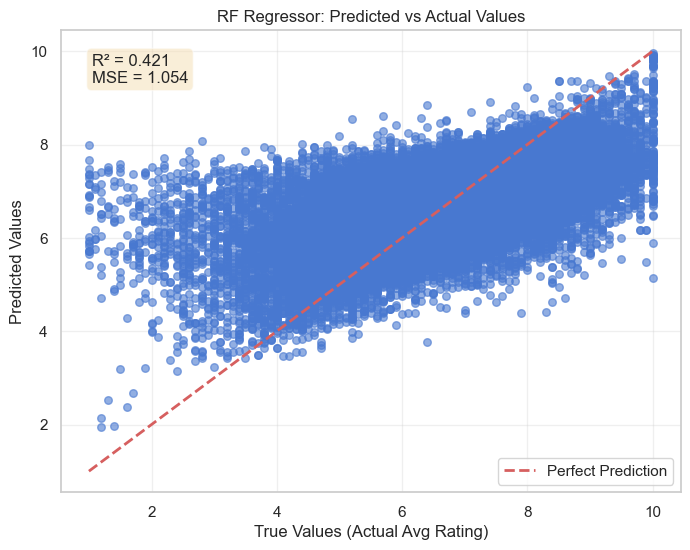

In [40]:
# Create scatterplot comparing predictions vs actual values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, s=30)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('True Values (Actual Avg Rating)')
plt.ylabel('Predicted Values')
plt.title('RF Regressor: Predicted vs Actual Values')
plt.legend()
plt.grid(True, alpha=0.3)

# Add R² and MSE to the plot
plt.text(0.05, 0.95, f'R² = {r2:.3f}\nMSE = {mse:.3f}', 
         transform=plt.gca().transAxes, fontsize=12, 
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.show()

Slightly better results than XGBoost

# Trying best model

In [17]:
best_params = {'clf__n_estimators': 500, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_features': 0.5, 'clf__max_depth': None}

In [18]:
pipeline.set_params(**best_params)
pipeline.fit(df_train, y_train)

,steps,"[('preprocessor', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('bool', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [19]:
y_pred = pipeline.predict(df_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Model Performance:")
print(f"MSE: {mse:.3f}")
print(f"R-squared: {r2:.3f}")

Model Performance:
MSE: 1.013
R-squared: 0.443


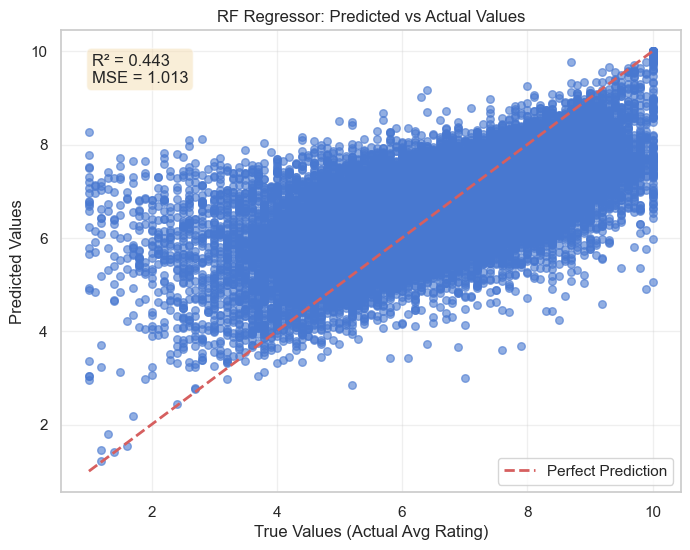

In [20]:
# Create scatterplot comparing predictions vs actual values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, s=30)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('True Values (Actual Avg Rating)')
plt.ylabel('Predicted Values')
plt.title('RF Regressor: Predicted vs Actual Values')
plt.legend()
plt.grid(True, alpha=0.3)

# Add R² and MSE to the plot
plt.text(0.05, 0.95, f'R² = {r2:.3f}\nMSE = {mse:.3f}', 
         transform=plt.gca().transAxes, fontsize=12, 
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.show()

better results

In [22]:
from scipy.stats import pearsonr, spearmanr
pearson_corr, _ = pearsonr(y_test, y_pred)
spearman_corr, _ = spearmanr(y_test, y_pred)

print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"Spearman correlation: {spearman_corr:.3f}")

Pearson correlation: 0.667
Spearman correlation: 0.670
